<a href="https://colab.research.google.com/github/Krishishah7/ai-learning-series/blob/main/01_machine_learning_foundations/41_adaboost_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import AdaBoostClassifier

from sklearn.metrics import accuracy_score

In [2]:
X, y = make_classification(
    n_samples=500,
    n_features=10,
    n_informative=5,
    random_state=42
)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [4]:
stump = DecisionTreeClassifier(
    max_depth=1,
    random_state=42
)

stump.fit(
    X_train,
    y_train
)

stump_pred = stump.predict(
    X_test
)

stump_acc = accuracy_score(
    y_test,
    stump_pred
)

print(
    "Decision Stump Accuracy:",
    stump_acc
)

Decision Stump Accuracy: 0.73


In [5]:
ada = AdaBoostClassifier(
    n_estimators=50,
    random_state=42
)

ada.fit(
    X_train,
    y_train
)

ada_pred = ada.predict(
    X_test
)

ada_acc = accuracy_score(
    y_test,
    ada_pred
)

print(
    "AdaBoost Accuracy:",
    ada_acc
)

AdaBoost Accuracy: 0.9


In [6]:
comparison = pd.DataFrame({
    "Model":[
        "Decision Stump",
        "AdaBoost"
    ],

    "Accuracy":[
        stump_acc,
        ada_acc
    ]
})

comparison

,Model,Accuracy
0,Decision Stump,0.73
1,AdaBoost,0.90


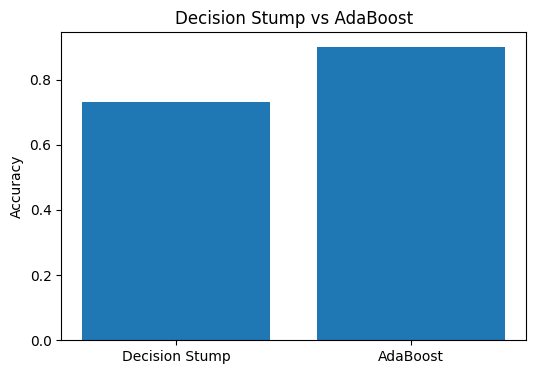

In [7]:
plt.figure(figsize=(6,4))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.ylabel("Accuracy")

plt.title(
    "Decision Stump vs AdaBoost"
)

plt.show()

In [8]:
results = []

for n in [10, 25, 50, 100]:

    model = AdaBoostClassifier(
        n_estimators=n,
        random_state=42
    )

    model.fit(
        X_train,
        y_train
    )

    pred = model.predict(
        X_test
    )

    acc = accuracy_score(
        y_test,
        pred
    )

    results.append(
        [n, acc]
    )

In [9]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Estimators",
        "Accuracy"
    ]
)

results_df

,Estimators,Accuracy
0,10,0.82
1,25,0.87
2,50,0.90
3,100,0.90


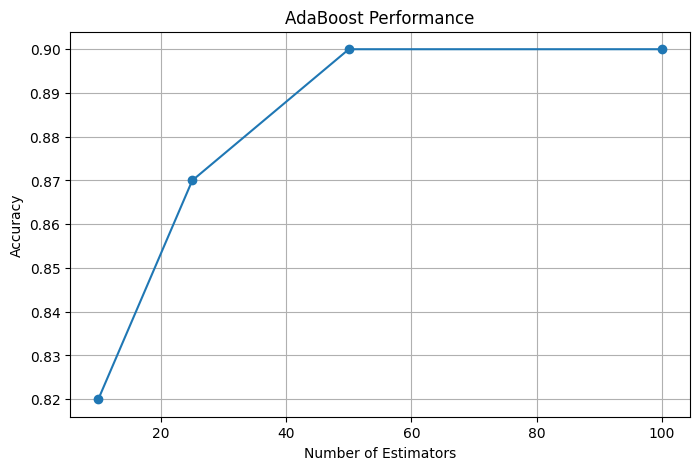

In [10]:
plt.figure(figsize=(8,5))

plt.plot(
    results_df["Estimators"],
    results_df["Accuracy"],
    marker='o'
)

plt.xlabel("Number of Estimators")

plt.ylabel("Accuracy")

plt.title(
    "AdaBoost Performance"
)

plt.grid()

plt.show()

## Conclusion

AdaBoost combines multiple weak learners into a stronger model.

Observations:
- Individual weak learners have limited performance.
- AdaBoost improves performance by focusing on difficult examples.
- Increasing estimators can improve performance up to a point.
- Boosting learns sequentially from previous mistakes.